In [1]:
from matplotlib import pyplot as plt

from cr_knee_fit import experiments
from cr_knee_fit.elements import Element
from cr_knee_fit.fit_data import Data, DataConfig, FluxRatio

✅ AMS-02 H
✅ AMS-02 He
✅ AMS-02 Li
✅ AMS-02 Be
✅ AMS-02 B
✅ AMS-02 C
✅ AMS-02 N
✅ AMS-02 O
✅ AMS-02 F
✅ AMS-02 Ne
❌ AMS-02 Na: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Na_energy.txt not found.
✅ AMS-02 Mg
✅ AMS-02 Al
✅ AMS-02 Si
❌ AMS-02 P: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_P_energy.txt not found.
✅ AMS-02 S
❌ AMS-02 Cl: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Cl_energy.txt not found.
❌ AMS-02 Ar: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ar_energy.txt not found.
❌ AMS-02 K: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_K_energy.txt not found.
❌ AMS-02 Ca: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ca_energy.txt not found.
❌ AMS-02 Sc: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Sc_energy.txt not found.
❌ AMS-02 Ti: /Users/njvh/Documents/Sci

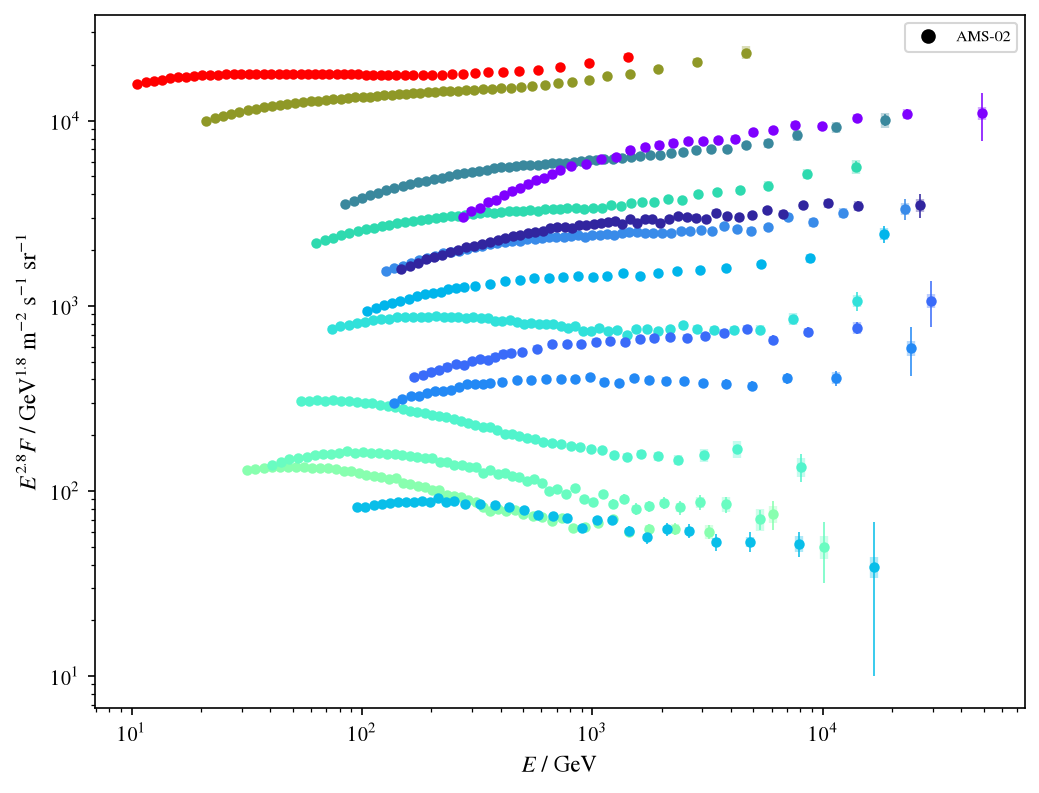

In [2]:
conf = DataConfig(
    experiments_elements=[experiments.ams02],
    default_elements=Element.regular(),
    elements_R_bounds=(1e1, 1e5),
    aux_data=[
        (experiments.ams02, FluxRatio(Element.H, Element.He)),
        (experiments.ams02, FluxRatio(Element.Li, Element.B)),
        (experiments.ams02, FluxRatio(Element.B, Element.C)),
        (experiments.ams02, FluxRatio(Element.B, Element.O)),
        (experiments.ams02, FluxRatio(Element.Be, Element.B)),
        (experiments.ams02, FluxRatio(Element.C, Element.O)),
        (experiments.ams02, FluxRatio(Element.Fe, Element.O)),
    ],
)

d = Data.load(conf, verbose=True)
d.plot(scale=2.8);

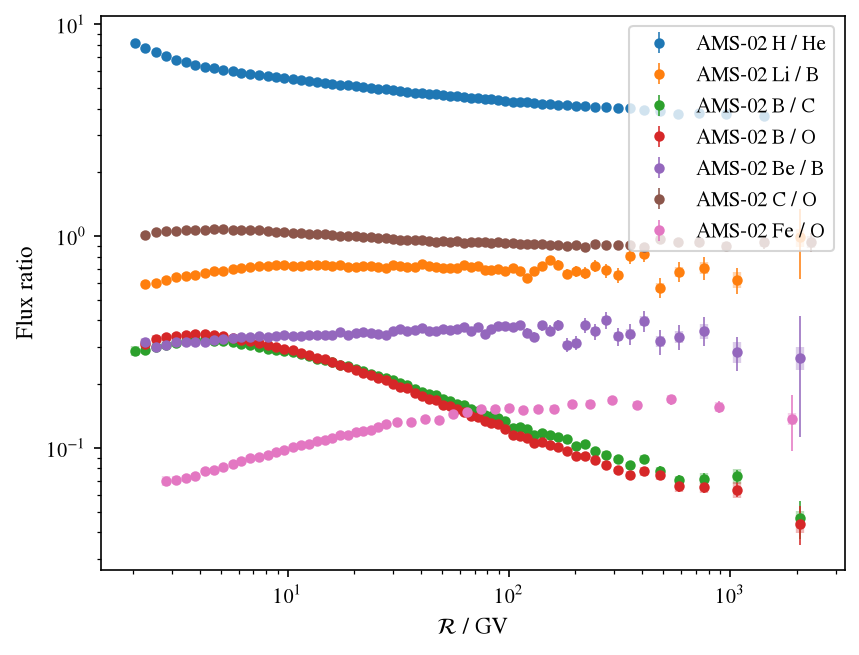

In [3]:
fig, ax = plt.subplots()
for fr in d.aux_data:
    fr.plot(ax=ax)

ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()

/Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/cr_knee_fit/crams_model.py:169: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.crams.compute(self.propagation, self.injection))


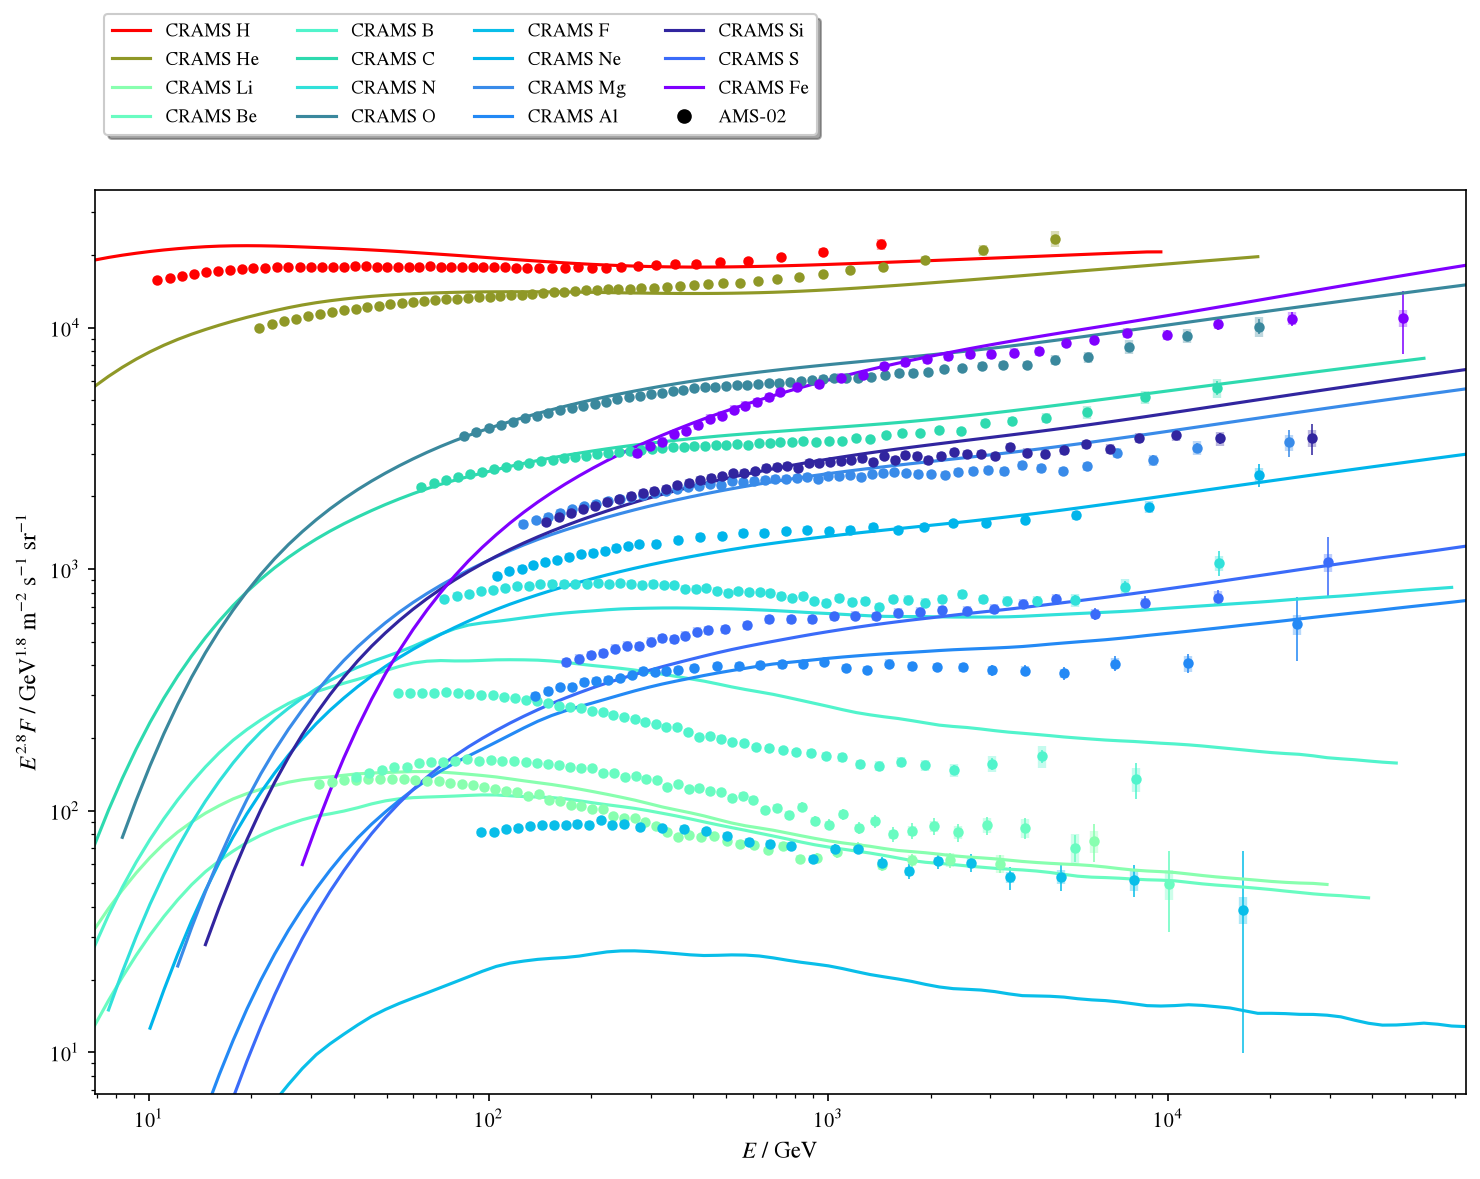

In [4]:
from crams import InjectionParams, PropagationParams

from cr_knee_fit.crams_model import CramsModel, CramsModelConfig
from cr_knee_fit.model import Model
from cr_knee_fit.shifts import ExperimentEnergyScaleShifts

m = Model(
    populations=[],
    energy_shifts=ExperimentEnergyScaleShifts(lg_shifts={}),
    crams=CramsModel(
        propagation=PropagationParams(),
        injection=InjectionParams.default(),
        config=CramsModelConfig.default(),
    ),
)

m.plot_spectra(fit_data=d, scale=2.8);